## Подготовка данных с использованием фреймворка Apache Spark

Подключим необходимые библиотеки.

In [1]:
import os
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.sql.functions import (
    regexp_replace,
    regexp_extract_all,
    regexp_extract,
    col,
    lit,
    when,
    to_date,
    from_unixtime,
    split,
    trim,
    year,
    udf, 
    array,
    expr
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.sql import functions as F
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml import Pipeline

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """

    conf = SparkConf()
    conf.setAppName("Load_DP")
    conf.setMaster("local[*]")
    conf.set("spark.driver.memory", "10g")           
    conf.set("spark.executor.memory", "15g")         
    conf.set("spark.memory.fraction", "0.8")        
    conf.set("spark.memory.storageFraction", "0.3") 
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

Для исследования будем использовать датасет, расположенный по адресу https://ods.ai/competitions/dl-fintech-bki/data.

Указываем путь.

In [5]:
database_name = "database"
path_features = f"{database_name}/train_features"

Заполняем датафрейм данными из файла.

In [6]:
train_features = spark.read.parquet(path_features)

Выводим фрагмент датафрейма на экран.

In [7]:
train_features.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

,id,features,flag,classWeight
0,3,"(294,[0,4,5,8,9,12,13,16,17,20,21,24,25,28,29,32,33,36,37,40,41,44,45,48,49,52,53,56,57,60,61,64,65,68,69,72,73,76,77,80,81,84,85,88,89,92,93,96,97,100,107,108,114,115,116,117,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,145,146,147,148,149,150,151,153,154,155,156,157,158,159,161,162,163,164,165,166,167,168,169,171,172,173,174,175,176,177,179,180,181,182,183,184,185,187,188,189,190,191,192,193,195,196,197,198,199,200,201,203,204,205,210,211,214,215,216,219,221,222,223,225,226,227,228,229,230,231,232,235,237,238,239,240,243,245,246,247,248,251,253,254,255,256,259,261,262,263,264,267,269,270,271,272,273,275,276,277,278,279,280,281,283,285,286,287,288,289,291,293],[15.0,14.0,1.0,14.0,1.0,14.0,1.0,14.0,1.0,14.0,1.0,13.0,2.0,13.0,2.0,13.0,2.0,12.0,3.0,6.0,9.0,6.0,9.0,6.0,9.0,7.0,8.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,8.0,7.0,10.0,5.0,15.0,8.0,7.0,9.0,4.0,1.0,1.0,15.0,8.0,15.0,1.0,4.47213595499958,15.0,14.0,8.0,7.0,18.0,1.0,5.424810727442149,15.0,-1.0,6.0,7.333333333333333,16.0,4.5303211281110665,0.06666666666666667,15.0,-5.0,9.0,7.6,16.0,5.803939548764639,0.06666666666666667,15.0,-7.0,4.0,7.8,16.0,4.459340117743239,0.13333333333333333,15.0,10.0,8.0,5.2,16.0,1.0,4.7539457296018846,15.0,-5.0,3.0,8.133333333333333,12.0,2.0,3.5023801430836525,15.0,3.0,10.0,9.866666666666667,18.0,1.0,5.717974999528949,15.0,4.0,11.0,2.6,6.0,1.0,1.2421180068162376,15.0,-1.0,2.0,3.2666666666666666,5.0,2.0,0.7988086367179803,15.0,-1.0,3.0,1.0,15.0,2.0,2.0,2.0,15.0,2.0,4.466666666666667,9.0,2.695675549220764,0.06666666666666667,15.0,-3.0,4.0,6.0,6.0,6.0,15.0,6.0,16.0,16.0,16.0,15.0,16.0,5.0,5.0,5.0,15.0,5.0,4.0,4.0,4.0,15.0,4.0,8.0,8.0,8.0,15.0,8.0,12.2,18.0,2.0,5.69711706542378,15.0,-10.0,16.0,2.2,5.0,2.0,0.7745966692414835,15.0,2.0,16.133333333333333,17.0,4.0,3.3565855667130946,15.0,17.0])",0,1.00
1,20,"(294,[0,1,2,4,5,6,8,9,12,13,14,16,17,20,21,24,25,28,29,32,33,36,37,40,41,44,45,48,49,52,53,56,57,60,61,64,65,68,69,72,73,76,77,80,81,84,85,88,89,92,93,96,97,100,107,108,109,114,115,116,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,144,145,147,148,149,150,151,152,153,155,156,157,158,159,160,161,163,164,165,166,167,168,169,171,172,173,174,175,176,177,179,180,181,182,183,184,185,187,189,190,191,192,193,195,196,197,198,199,200,201,203,205,210,211,214,215,216,219,221,222,223,224,225,227,228,229,230,231,232,235,237,238,239,240,243,245,246,247,248,251,253,254,255,256,259,261,262,263,264,267,269,270,271,272,273,275,276,277,278,279,280,281,283,285,286,287,288,289,291,293],[12.0,1.0,2.0,11.0,2.0,2.0,12.0,3.0,5.0,9.0,1.0,6.0,9.0,6.0,9.0,3.0,12.0,2.0,13.0,2.0,13.0,2.0,13.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,13.0,2.0,14.0,1.0,14.0,1.0,14.0,1.0,15.0,12.0,2.0,1.0,4.0,2.0,9.0,15.0,8.0,15.0,1.0,4.47213595499958,15.0,14.0,8.0,8.466666666666667,19.0,2.0,5.52742082280524,15.0,11.0,7.0,12.6,17.0,1.0,5.315744807375808,15.0,-5.0,14.0,6.4,17.0,4.0,3.621365172733304,15.0,-3.0,4.0,5.866666666666666,16.0,3.0,3.7391111752597546,15.0,2.0,6.0,7.6,16.0,1.0,5.395765535518172,15.0,-3.0,5.0,10.066666666666666,15.0,6.0,3.4942129027184086,15.0,2.0,9.0,7.733333333333333,18.0,4.0,5.202563470700446,15.0,4.0,2.1333333333333333,6.0,1.0,1.1254628677422753,15.0,-1.0,2.0,2.933333333333333,3.0,2.0,0.2581988897471611,15.0,3.0,1.0,15.0,2.0,2.0,2.0,15.0,2.0,5.2,9.0,1.0,2.177810171446801,15.0,1.0,6.0,6.0,6.0,6.0,15.0,6.0,16.0,16.0,16.0,15.0,16.0,5.0,5.0,5.0,15.0,5.0,4.0,4.0,4.0,15.0,4.0,8.0,8.0,8.0,15.0,8.0,14.466666666666667,16.0,1.0,4.138092498218173,15.0,-15.0,16.0,2.2,5.0,2.0,0.7745966692414834,15.0,2.0,16.133333333333333,17.0,4.0,3.3565855667130946,15.0,17.0])",1,28.74
2,40,"(294,[0,2,4,8,12,13,16,17,20,21,24,25,28,29,32,33,36,37,40,44,48,52,56,60,64,68,72,76,80,84,88,92,96,100,107,108,114,115,117,122,126,127,128,129,131,132,133,134,135,136,137,139,140,141,142,143,145,146,147,148,149,150,151,153,154,155,156,157,158,159,160

In [8]:
train_features.printSchema()

root
 |-- id: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- flag: integer (nullable = true)
 |-- classWeight: double (nullable = true)



In [9]:
# 1. Импортируем нужные библиотеки
from pyspark.ml.classification import GBTClassificationModel

# 2. Простая функция для загрузки
def load_model(model_path="models/gbt_model"):
    """
    Простая загрузка сохраненной модели GBT
    """
    print(f"Загружаю модель из {model_path}...")
    
    try:
        # Загружаем модель
        model = GBTClassificationModel.load(model_path)
        print("✓ Модель успешно загружена")
        return model
    except Exception as e:
        print(f"✗ Ошибка при загрузке: {e}")
        return None



In [10]:
# Загрузка модели
model = load_model("models/gbt_model")

# 4. Проверяем, что модель загрузилась
if model is not None:
    print(f"\nИнформация о модели:")
    print(f"  Тип: {type(model).__name__}")
    print(f"  UID: {model.uid}")

Загружаю модель из models/gbt_model...
✓ Модель успешно загружена

Информация о модели:
  Тип: GBTClassificationModel
  UID: GBTClassifier_d71bc0e16fff


In [11]:
def get_feature_importance(model, feature_names, top_n=20):
    """
    Возвращает топ-N признаков по важности
    """
    importances = model.featureImportances.toArray()

    feats = list(zip(feature_names, importances))
    feats = sorted(feats, key=lambda x: x[1], reverse=True)

    return feats[:top_n]

In [13]:
import json

with open("feature_names.json", "r", encoding="utf-8") as f:
    feature_names = json.load(f)

In [14]:
top_feats = get_feature_importance(
    model,
    feature_names,
    top_n=20
)

for name, score in top_feats:
    print(f"{name:45s} {score:.6f}")

enc_paym_23=2                                 0.066620
pre_loans530_notnull_count                    0.050768
pre_loans530_std                              0.038801
pre_loans530_zero_ratio                       0.033591
enc_paym_12=0                                 0.030453
enc_paym_23=0                                 0.030327
enc_paym_0=1                                  0.027786
pre_till_pclose_trend                         0.027003
enc_paym_1=0                                  0.026329
enc_paym_1=3                                  0.026230
pre_loans_next_pay_summ_zero_ratio            0.024318
enc_paym_2=0                                  0.023661
enc_paym_22=3                                 0.021093
pre_loans530_trend                            0.018079
enc_paym_3=3                                  0.016502
enc_paym_23=__unknown__                       0.014724
pre_loans_credit_limit_trend                  0.014565
enc_paym_2=1                                  0.014518
enc_paym_1

In [19]:
def analyze_feature_dependencies_spark(
    df,
    model,
    feature_names,
    features_col="features",
    label_col="flag",
    sample_fraction=0.1,
    top_n=20
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pyspark.sql.functions import col, udf, mean, stddev, corr, count
    from pyspark.sql.types import DoubleType

    print("=" * 90)
    print("АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)")
    print("=" * 90)

    # ------------------------------------------------------------------
    # Sample
    # ------------------------------------------------------------------
    df_sample = df.sample(fraction=sample_fraction, seed=42)

    # ------------------------------------------------------------------
    # Feature importances
    # ------------------------------------------------------------------
    importances = model.featureImportances.toArray()

    importance_tuples = [
        (i, feature_names[i], float(importances[i]))
        for i in range(len(importances))
    ]
    importance_tuples.sort(key=lambda x: x[2], reverse=True)

    print("\nТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:")
    for i, (_, name, imp) in enumerate(importance_tuples[:top_n], 1):
        print(f"{i:2d}. {name:45s} {imp:.6f}")

    top_features = importance_tuples[:top_n]

    # ------------------------------------------------------------------
    # Plot importances
    # ------------------------------------------------------------------
    plt.figure(figsize=(12, 7))
    plt.barh(
        range(top_n),
        [x[2] for x in reversed(top_features)],
        color=plt.cm.viridis(np.linspace(0, 1, top_n))
    )
    plt.yticks(
        range(top_n),
        [x[1] for x in reversed(top_features)]
    )
    plt.xlabel("Feature importance")
    plt.title("Top feature importances (GBT)")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # UDF extractor
    # ------------------------------------------------------------------
    def extract_feature(idx):
        def _extract(v):
            return float(v[idx]) if v is not None else 0.0
        return udf(_extract, DoubleType())

    # ------------------------------------------------------------------
    # Distribution analysis (TOP-6)
    # ------------------------------------------------------------------
    top6 = top_features[:6]

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (idx, name, imp) in zip(axes, top6):
        col_name = f"f_{idx}"

        df_feat = df_sample.withColumn(
            col_name,
            extract_feature(idx)(col(features_col))
        )

        stats = (
            df_feat
            .groupBy(label_col)
            .agg(
                mean(col_name).alias("mean"),
                stddev(col_name).alias("std"),
                count("*").alias("n")
            )
            .collect()
        )

        s0 = next((r for r in stats if r[label_col] == 0), None)
        s1 = next((r for r in stats if r[label_col] == 1), None)

        print(f"\n{name}")
        print(f"  importance = {imp:.6f}")
        print(f"  class 0: mean={s0['mean']:.4f} std={s0['std']:.4f}")
        print(f"  class 1: mean={s1['mean']:.4f} std={s1['std']:.4f}")

        # histogram sample
        hist = df_feat.sample(0.1, seed=42).select(col_name, label_col).collect()
        v0 = [r[col_name] for r in hist if r[label_col] == 0]
        v1 = [r[col_name] for r in hist if r[label_col] == 1]

        ax.hist(v0, bins=30, alpha=0.5, density=True, label="class 0")
        ax.hist(v1, bins=30, alpha=0.5, density=True, label="class 1")
        ax.set_title(name, fontsize=10)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle("Feature distributions by class", fontsize=14)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # Correlation
    # ------------------------------------------------------------------
    print("\nКОРРЕЛЯЦИЯ С TARGET:")
    corr_results = []

    for idx, name, imp in top_features[:10]:
        df_feat = df_sample.withColumn(
            "tmp",
            extract_feature(idx)(col(features_col))
        )

        c = (
            df_feat
            .select(corr("tmp", label_col).alias("corr"))
            .collect()[0]["corr"]
        ) or 0.0

        corr_results.append((name, c, imp))
        print(f"{name:45s} corr={c:.4f} importance={imp:.6f}")

    df_sample.unpersist()

    return {
        "top_features": top_features,
        "correlations": corr_results,
    }


АНАЛИЗ ЗАВИСИМОСТИ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ОТ ПРИЗНАКОВ (feature_names)

ТОП ПРИЗНАКОВ ПО ВАЖНОСТИ:
 1. enc_paym_23=2                                 0.066620
 2. pre_loans530_notnull_count                    0.050768
 3. pre_loans530_std                              0.038801
 4. pre_loans530_zero_ratio                       0.033591
 5. enc_paym_12=0                                 0.030453
 6. enc_paym_23=0                                 0.030327
 7. enc_paym_0=1                                  0.027786
 8. pre_till_pclose_trend                         0.027003
 9. enc_paym_1=0                                  0.026329
10. enc_paym_1=3                                  0.026230
11. pre_loans_next_pay_summ_zero_ratio            0.024318
12. enc_paym_2=0                                  0.023661
13. enc_paym_22=3                                 0.021093
14. pre_loans530_trend                            0.018079
15. enc_paym_3=3                                  0.016502
16. enc_paym_23=__un

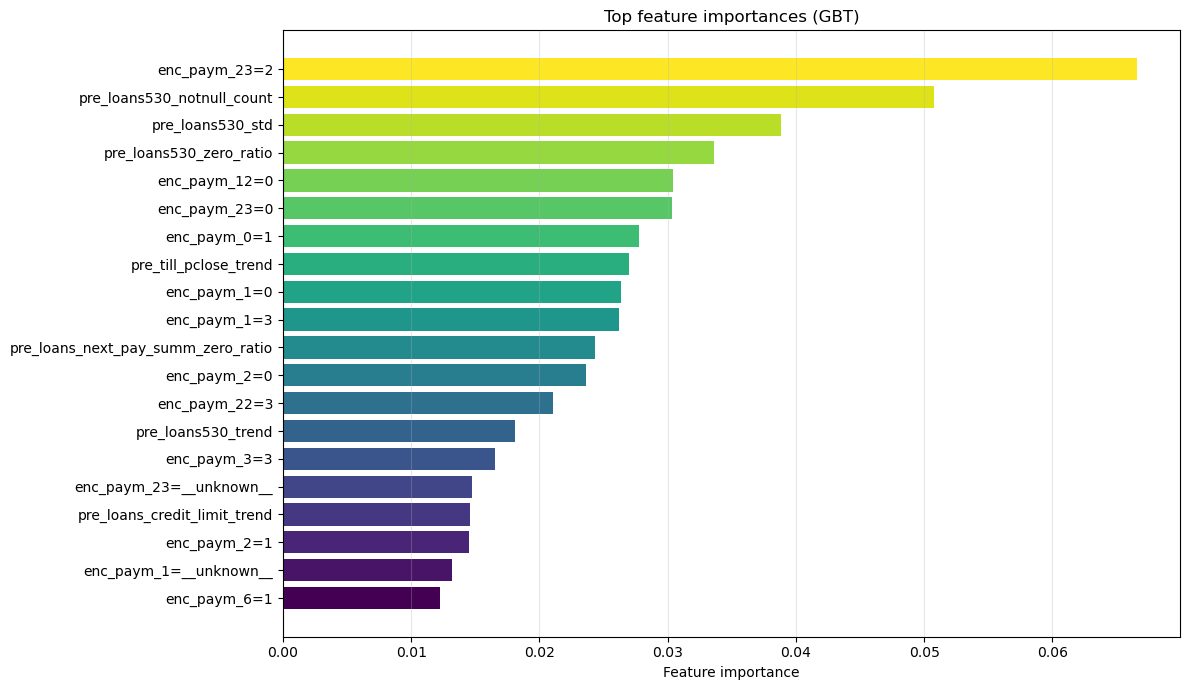


enc_paym_23=2
  importance = 0.066620
  class 0: mean=0.2569 std=0.5885
  class 1: mean=0.1351 std=0.4228

pre_loans530_notnull_count
  importance = 0.050768
  class 0: mean=6.3998 std=5.1970
  class 1: mean=5.9954 std=5.0150

pre_loans530_std
  importance = 0.038801
  class 0: mean=13.3395 std=2.6769
  class 1: mean=12.7151 std=3.1234

pre_loans530_zero_ratio
  importance = 0.033591
  class 0: mean=16.0805 std=2.5140
  class 1: mean=15.7486 std=3.1965

enc_paym_12=0
  importance = 0.030453
  class 0: mean=2.5847 std=2.4251
  class 1: mean=1.9565 std=2.2005

enc_paym_23=0
  importance = 0.030327
  class 0: mean=0.3356 std=1.5556
  class 1: mean=0.7070 std=2.4261


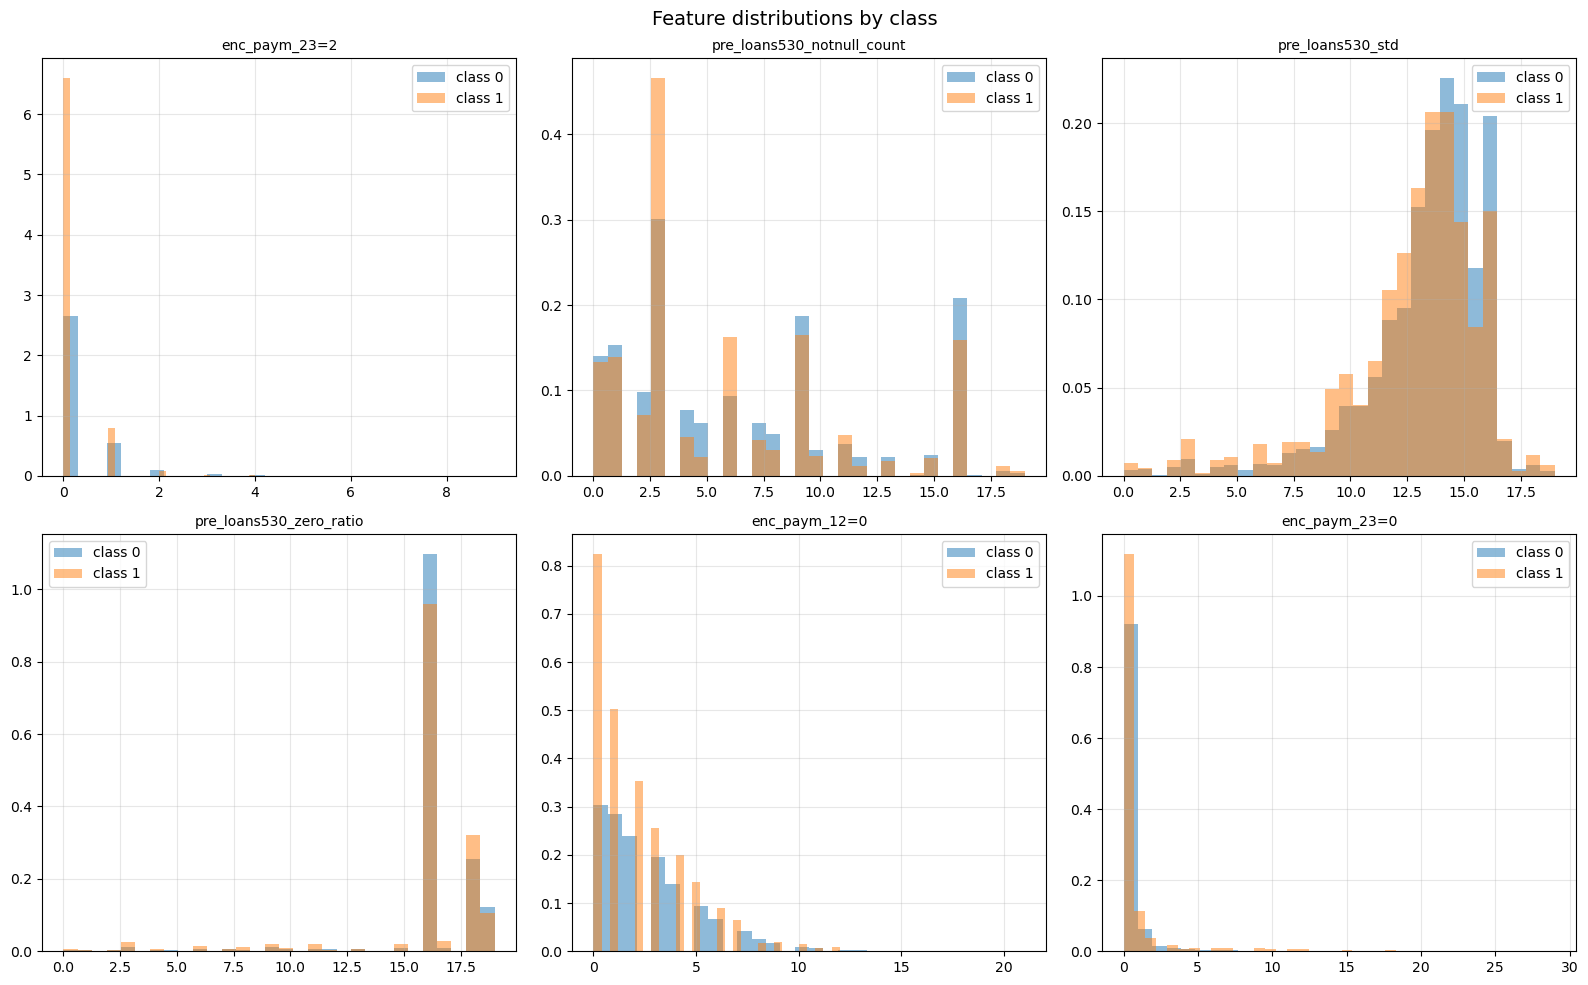


КОРРЕЛЯЦИЯ С TARGET:
enc_paym_23=2                                 corr=-0.0384 importance=0.066620
pre_loans530_notnull_count                    corr=-0.0143 importance=0.050768
pre_loans530_std                              corr=-0.0426 importance=0.038801
pre_loans530_zero_ratio                       corr=-0.0240 importance=0.033591
enc_paym_12=0                                 corr=-0.0478 importance=0.030453
enc_paym_23=0                                 corr=0.0428 importance=0.030327
enc_paym_0=1                                  corr=0.0477 importance=0.027786
pre_till_pclose_trend                         corr=0.0090 importance=0.027003
enc_paym_1=0                                  corr=0.0476 importance=0.026329
enc_paym_1=3                                  corr=0.0368 importance=0.026230


In [20]:
results = analyze_feature_dependencies_spark(
    train_features,
    model=model,
    feature_names=feature_names,
    sample_fraction=0.1,
    top_n=20
)

После сессию `Apache Spark`.

In [21]:
spark.stop()